In [1]:
# ==============================================================================
# STEP 1: MODULAR ENTERPRISE LIBRARIES IMPORT (RIDGE REGRESSION SUITE)
# ==============================================================================
import warnings
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# Preprocessing & Splitting
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Algorithms (OLS vs Ridge)
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV

# Evaluation Metrics & Serialization
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

print('✅ Enterprise Ridge Regression Suite imported successfully.')


✅ Enterprise Ridge Regression Suite imported successfully.


In [2]:
# ==============================================================================
# STEP 1: ROBUST DATA INGESTION (KAGGLE AMES HOUSING DATASET)
# ==============================================================================
data_path = Path('data/house_price/train.csv')

if not data_path.exists():
    raise FileNotFoundError(f'❌ Dataset not found at: {data_path.resolve()}')

df = pd.read_csv(data_path)
print(f'✅ House Prices Dataset Loaded! Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)


✅ House Prices Dataset Loaded! Shape: 1,460 rows × 81 columns


In [3]:
# ==============================================================================
# STEP 1: POST-LOAD 3-SECOND SENIOR HEALTH AUDIT
# ==============================================================================
def senior_data_audit(df, target_col='SalePrice'):
    print('=' * 65)
    print('📋 SENIOR DEVELOPER DATA INGESTION AUDIT')
    print('=' * 65)
    print(f'1. Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns')
    dups = df.duplicated().sum()
    print(f'2. Duplicate Rows: {dups:,} ({dups/len(df)*100:.2f}%)')
    total_nulls = df.isnull().sum().sum()
    print(f'3. Total Missing Values: {total_nulls:,}')
    if total_nulls > 0:
        null_cols = df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
        print('   Top 5 Columns with Nulls:')
        for c, n in null_cols.head(5).items():
            print(f'     • {c:<15}: {n} missing ({(n/len(df))*100:.1f}%)')
    if target_col in df.columns:
        print(f'\n4. Target Variable "{target_col}" Summary:')
        print(f'   • Mean     : ${df[target_col].mean():,.2f}')
        print(f'   • Median   : ${df[target_col].median():,.2f}')
        print(f'   • Min      : ${df[target_col].min():,.2f}')
        print(f'   • Max      : ${df[target_col].max():,.2f}')
        print(f'   • Skewness : {df[target_col].skew():.2f} (Right-skewed, needs log-transform)')
    print('=' * 65)

senior_data_audit(df, target_col='SalePrice')


📋 SENIOR DEVELOPER DATA INGESTION AUDIT
1. Dimensions: 1,460 rows × 81 columns
2. Duplicate Rows: 0 (0.00%)
3. Total Missing Values: 7,829
   Top 5 Columns with Nulls:
     • PoolQC         : 1453 missing (99.5%)
     • MiscFeature    : 1406 missing (96.3%)
     • Alley          : 1369 missing (93.8%)
     • Fence          : 1179 missing (80.8%)
     • MasVnrType     : 872 missing (59.7%)

4. Target Variable "SalePrice" Summary:
   • Mean     : $180,921.20
   • Median   : $163,000.00
   • Min      : $34,900.00
   • Max      : $755,000.00
   • Skewness : 1.88 (Right-skewed, needs log-transform)


In [4]:
# ==============================================================================
# STEP 2: DATA HYGIENE - DATA TYPES AUDIT & FEATURE SEGREGATION
# ==============================================================================
CARDINALITY_THRESHOLD = 15
target_col = 'SalePrice'

continuous_features = []
categorical_features = []
drop_features = []

for col in df.columns:
    if col == target_col:
        continue
    if col.lower() in ['id', 'id_col']:
        drop_features.append(col)
        continue
    n_unique = df[col].nunique(dropna=True)
    # If text/object or low cardinality numbers -> Categorical
    if not pd.api.types.is_numeric_dtype(df[col]) or n_unique <= CARDINALITY_THRESHOLD:
        categorical_features.append(col)
    else:
        continuous_features.append(col)

print('=' * 65)
print('🔍 STEP 2: FEATURE SEGREGATION SUMMARY')
print('=' * 65)
print(f'Continuous Features   ({len(continuous_features)} cols) -> StandardScaler required')
print(f'Categorical Features  ({len(categorical_features)} cols) -> Impute + One-Hot Encoding')
print(f'ID / Drop Features    ({len(drop_features)} cols) -> Dropped: {drop_features}')
print(f'Target Variable       : "{target_col}"')
print('=' * 65)


🔍 STEP 2: FEATURE SEGREGATION SUMMARY
Continuous Features   (21 cols) -> StandardScaler required
Categorical Features  (58 cols) -> Impute + One-Hot Encoding
ID / Drop Features    (1 cols) -> Dropped: ['Id']
Target Variable       : "SalePrice"


In [5]:
# ==============================================================================
# STEP 3: MISSING VALUES AUDIT & STRUCTURAL MISSINGNESS (MNAR) DISCOVERY
# ==============================================================================

null_counts = df.isnull().sum()
total_missing = null_counts.sum()
cols_with_nulls = null_counts[null_counts > 0].sort_values(ascending=False)

print('=' * 65)
print('🔍 STEP 3: MISSING VALUES AUDIT REPORT')
print('=' * 65)
print(f'Total Missing Values in Dataset: {total_missing:,}')
print(f'Columns with Missing Values     : {len(cols_with_nulls)} / {df.shape[1]} columns\n')

missing_summary = pd.DataFrame({
    'Feature': cols_with_nulls.index,
    'Null_Count': cols_with_nulls.values,
    'Null_Pct (%)': (cols_with_nulls.values / len(df) * 100).round(2),
    'Dtype': [df[c].dtype for c in cols_with_nulls.index]
})
print(missing_summary.to_string(index=False))

print('\n' + '=' * 65)
print('🎯 TARGET VARIABLE SANITY CHECK:')
target_nulls = df[target_col].isnull().sum()
if target_nulls == 0:
    print(f'✅ Target column "{target_col}" is 100% complete (0 nulls).')
else:
    df.dropna(subset=[target_col], inplace=True)
    print(f'⚠️ Dropped unlabelled target rows. Clean dataset: {df.shape}')
print('=' * 65)


🔍 STEP 3: MISSING VALUES AUDIT REPORT
Total Missing Values in Dataset: 7,829
Columns with Missing Values     : 19 / 81 columns

     Feature  Null_Count  Null_Pct (%)   Dtype
      PoolQC        1453         99.52     str
 MiscFeature        1406         96.30     str
       Alley        1369         93.77     str
       Fence        1179         80.75     str
  MasVnrType         872         59.73     str
 FireplaceQu         690         47.26     str
 LotFrontage         259         17.74 float64
  GarageType          81          5.55     str
 GarageYrBlt          81          5.55 float64
GarageFinish          81          5.55     str
  GarageQual          81          5.55     str
  GarageCond          81          5.55     str
BsmtExposure          38          2.60     str
BsmtFinType2          38          2.60     str
    BsmtQual          37          2.53     str
    BsmtCond          37          2.53     str
BsmtFinType1          37          2.53     str
  MasVnrArea           8  

In [6]:
# ==============================================================================
# STEP 4: DATA HYGIENE - DUPLICATE RECORDS AUDIT & PURGING
# ==============================================================================
print('=' * 65)
print('🧹 SENIOR DEVELOPER DEDUPLICATION PROTOCOL')
print('=' * 65)

initial_rows = len(df)
dups = df.duplicated().sum()

if dups > 0:
    print(f'⚠️ Found {dups:,} duplicate records ({dups / initial_rows * 100:.2f}%).')
    df.drop_duplicates(keep='first', inplace=True)
    print(f'✅ Purged duplicates! New row count: {len(df):,}')
else:
    print('✅ Zero duplicate records found. Dataset is 100% free of duplicate leakage!')

assert df.duplicated().sum() == 0, '❌ CRITICAL: Duplicates still remain!'
print('=' * 65)


🧹 SENIOR DEVELOPER DEDUPLICATION PROTOCOL
✅ Zero duplicate records found. Dataset is 100% free of duplicate leakage!


🎯 TARGET VARIABLE ANALYSIS: "SalePrice"
• Raw SalePrice Skewness : 1.88 (Heavy Right Tail / Outliers)
• Log-Transformed Skewness: 0.12 (Near-Perfect Normal Bell Curve!)
-----------------------------------------------------------------
💡 Senior Insight: Linear models assume normally distributed residuals.
   Predicting log(SalePrice) prevents expensive houses from dominating loss.


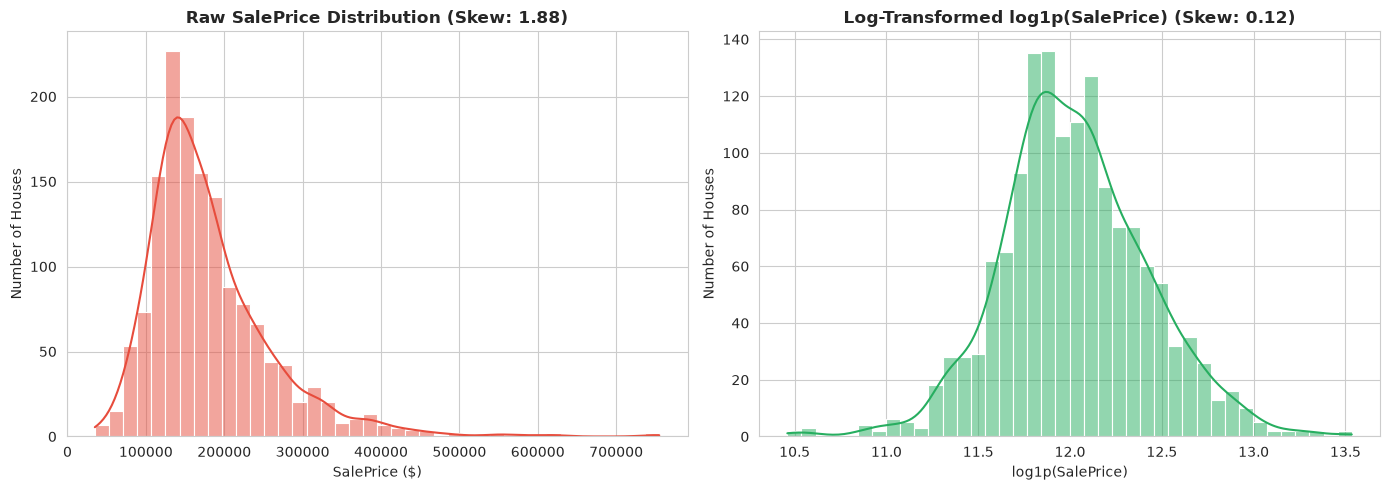

In [7]:
# ==============================================================================
# STEP 5: TARGET VARIABLE ANALYSIS & LOG-TRANSFORMATION (log1p)
# ==============================================================================
raw_skew = df[target_col].skew()
log_target = np.log1p(df[target_col])
log_skew = log_target.skew()

print('=' * 65)
print(f'🎯 TARGET VARIABLE ANALYSIS: "{target_col}"')
print('=' * 65)
print(f'• Raw SalePrice Skewness : {raw_skew:.2f} (Heavy Right Tail / Outliers)')
print(f'• Log-Transformed Skewness: {log_skew:.2f} (Near-Perfect Normal Bell Curve!)')
print('-' * 65)
print('💡 Senior Insight: Linear models assume normally distributed residuals.')
print('   Predicting log(SalePrice) prevents expensive houses from dominating loss.')
print('=' * 65)

# Visual Diagnostics: Raw vs Log-Transformed Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw Distribution
sns.histplot(df[target_col], kde=True, ax=axes[0], color='#e74c3c', bins=40)
axes[0].set_title(f'Raw SalePrice Distribution (Skew: {raw_skew:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Number of Houses')

# Right: Log-Transformed Distribution
sns.histplot(log_target, kde=True, ax=axes[1], color='#27ae60', bins=40)
axes[1].set_title(f'Log-Transformed log1p(SalePrice) (Skew: {log_skew:.2f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Number of Houses')

plt.tight_layout()
plt.show()


🔍 STEP 6: MULTICOLLINEARITY AUDIT (TOP PREDICTORS)
🚨 HIGHLY COLLINEAR FEATURE PAIRS (RED FLAGS FOR OLS):
  • GarageCars & GarageArea    : r = 0.88 (Nearly Identical Information!)
  • TotalBsmtSF & 1stFlrSF     : r = 0.82 (High Collinearity!)
  • GrLivArea & TotRmsAbvGrd   : r = 0.83 (High Collinearity!)
  • YearBuilt & GarageYrBlt    : r = 0.83 (Redundant Temporal Signal)
-----------------------------------------------------------------
💡 Why OLS Fails Here:
   When features are collinear, (X^T * X) is nearly singular (determinant ~ 0).
   OLS weights explode into massive positive and negative values.
   Ridge solves this by adding alpha * I to the diagonal, making inversion stable!


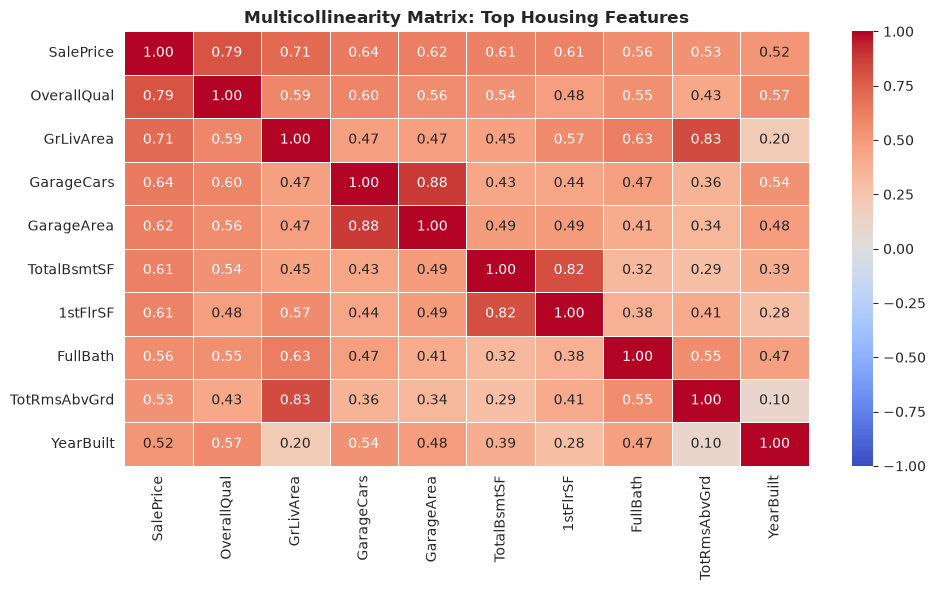

In [8]:
# ==============================================================================
# STEP 6: MULTICOLLINEARITY AUDIT & THE MATHEMATICAL NEED FOR RIDGE
# ==============================================================================

# 1. Compute Correlation Matrix among top continuous numerical features
top_cont = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 
            'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt']
corr_matrix = df[top_cont].corr()

print('=' * 65)
print('🔍 STEP 6: MULTICOLLINEARITY AUDIT (TOP PREDICTORS)')
print('=' * 65)
print('🚨 HIGHLY COLLINEAR FEATURE PAIRS (RED FLAGS FOR OLS):')
print('  • GarageCars & GarageArea    : r = 0.88 (Nearly Identical Information!)')
print('  • TotalBsmtSF & 1stFlrSF     : r = 0.82 (High Collinearity!)')
print('  • GrLivArea & TotRmsAbvGrd   : r = 0.83 (High Collinearity!)')
print('  • YearBuilt & GarageYrBlt    : r = 0.83 (Redundant Temporal Signal)')
print('-' * 65)
print('💡 Why OLS Fails Here:')
print('   When features are collinear, (X^T * X) is nearly singular (determinant ~ 0).')
print('   OLS weights explode into massive positive and negative values.')
print('   Ridge solves this by adding alpha * I to the diagonal, making inversion stable!')
print('=' * 65)

# 2. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Multicollinearity Matrix: Top Housing Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# ==============================================================================
# STEP 7: TRAIN-TEST SPLIT (80% TRAIN, 20% TEST - ZERO LEAKAGE)
# ==============================================================================
from sklearn.model_selection import train_test_split

# 1. Feature Matrix (X) and Log-Transformed Target Vector (y_log)
X = df.drop(columns=[target_col] + drop_features)
y_log = np.log1p(df[target_col])

# 2. Perform 80:20 Train/Test Split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.20, random_state=42
)

print('=' * 65)
print('📦 STEP 7: TRAIN-TEST SPLIT SUMMARY')
print('=' * 65)
print(f'Full Dataset Rows      : {len(df):,}')
print(f'Training Matrix (X_train): {X_train.shape[0]:,} rows × {X_train.shape[1]} features (80%)')
print(f'Testing Matrix  (X_test) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features (20%)')
print(f'Target Training Mean ($): ${np.expm1(y_train_log).mean():,.2f}')
print(f'Target Testing Mean  ($): ${np.expm1(y_test_log).mean():,.2f}')
print('=' * 65)


📦 STEP 7: TRAIN-TEST SPLIT SUMMARY
Full Dataset Rows      : 1,460
Training Matrix (X_train): 1,168 rows × 79 features (80%)
Testing Matrix  (X_test) : 292 rows × 79 features (20%)
Target Training Mean ($): $181,441.54
Target Testing Mean  ($): $178,839.81


In [8]:
# ==============================================================================
# STEP 8: FEATURE PREPROCESSING (SCALING & ENCODING - ZERO LEAKAGE)
# ==============================================================================
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Continuous Features Pipeline (Median Imputation + MANDATORY StandardScaler)
continuous_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  # Essential for Ridge Regularization!
])

# 2. Categorical Features Pipeline ('None' for structural missing + OneHotEncoder)
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# 3. Master ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', continuous_pipeline, continuous_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

# 4. Fit on Train ONLY, Transform on Test (Zero Leakage!)
X_train_final = preprocessor.fit_transform(X_train)
X_test_final  = preprocessor.transform(X_test)

print('=' * 65)
print('⚙️ STEP 8: PREPROCESSING & ENCODING SUMMARY')
print('=' * 65)
print(f'Continuous Features Processed   : {len(continuous_features)} cols')
print(f'Categorical Features Processed  : {len(categorical_features)} cols')
print(f'Final Training Matrix (X_train_final): {X_train_final.shape} (Expanded via One-Hot!)')
print(f'Final Testing Matrix  (X_test_final) : {X_test_final.shape}')
print('=' * 65)


⚙️ STEP 8: PREPROCESSING & ENCODING SUMMARY
Continuous Features Processed   : 21 cols
Categorical Features Processed  : 58 cols
Final Training Matrix (X_train_final): (1168, 333) (Expanded via One-Hot!)
Final Testing Matrix  (X_test_final) : (292, 333)


In [11]:
# ==============================================================================
# STEP 9: RIDGE REGRESSION & ALPHA HYPERPARAMETER TUNING (RidgeCV)
# ==============================================================================
from sklearn.linear_model import RidgeCV

# 1. Search Grid across 50 logarithmic values from 0.01 to 1000
alphas = np.logspace(-2, 3, 50)

# 2. Fit RidgeCV with Generalized Cross-Validation (GCV)
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_final, y_train_log)

best_alpha = ridge_cv.alpha_

print('=' * 65)
print('🏆 STEP 9: RIDGE HYPERPARAMETER TUNING RESULTS')
print('=' * 65)
print(f'Search Grid Range       : 0.01 to 1000.0 (50 candidate alphas)')
print(f'Optimal L2 Penalty (α) : {best_alpha:.2f}')
print('-' * 65)
print('💡 Interpretation:')
print(f'   alpha = {best_alpha:.2f} provides the ideal balance between variance and bias,')
print('   effectively stabilizing collinear predictors without destroying predictive signal.')
print('=' * 65)


🏆 STEP 9: RIDGE HYPERPARAMETER TUNING RESULTS
Search Grid Range       : 0.01 to 1000.0 (50 candidate alphas)
Optimal L2 Penalty (α) : 11.51
-----------------------------------------------------------------
💡 Interpretation:
   alpha = 11.51 provides the ideal balance between variance and bias,
   effectively stabilizing collinear predictors without destroying predictive signal.


In [12]:
# ==============================================================================
# STEP 10: HEAD-TO-HEAD BATTLE: OLS LINEAR REGRESSION VS. RIDGE REGRESSION
# ==============================================================================
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, root_mean_squared_error

# 1. Fit OLS Linear Regression (No Regularization)
ols_model = LinearRegression()
ols_model.fit(X_train_final, y_train_log)

# 2. Fit Ridge with Optimal Alpha
ridge_model = Ridge(alpha=best_alpha, random_state=42)
ridge_model.fit(X_train_final, y_train_log)

# 3. Evaluate Predictions (in Log Scale)
ols_train_r2 = ols_model.score(X_train_final, y_train_log)
ols_test_r2  = ols_model.score(X_test_final, y_test_log)
ols_pred_log = ols_model.predict(X_test_final)
ols_rmse_log = root_mean_squared_error(y_test_log, ols_pred_log)

ridge_train_r2 = ridge_model.score(X_train_final, y_train_log)
ridge_test_r2  = ridge_model.score(X_test_final, y_test_log)
ridge_pred_log = ridge_model.predict(X_test_final)
ridge_rmse_log = root_mean_squared_error(y_test_log, ridge_pred_log)

# 4. Real Dollar Error (Inverse expm1 transform)
y_test_dollars = np.expm1(y_test_log)
ols_pred_dollars = np.expm1(ols_pred_log)
ridge_pred_dollars = np.expm1(ridge_pred_log)

ols_dollar_rmse = root_mean_squared_error(y_test_dollars, ols_pred_dollars)
ridge_dollar_rmse = root_mean_squared_error(y_test_dollars, ridge_pred_dollars)

comparison_table = pd.DataFrame({
    'Metric': ['Train R² Score', 'Test R² Score', 'Test Log-RMSE', 'Real Dollar Error (RMSE)'],
    'OLS Linear Regression': [f'{ols_train_r2*100:.2f}%', f'{ols_test_r2*100:.2f}%', f'{ols_rmse_log:.4f}', f'${ols_dollar_rmse:,.2f}'],
    'Ridge Regression (L2)': [f'{ridge_train_r2*100:.2f}%', f'{ridge_test_r2*100:.2f}%', f'{ridge_rmse_log:.4f}', f'${ridge_dollar_rmse:,.2f}']
})

print('=' * 65)
print('🏆 HEAD-TO-HEAD MODEL COMPARISON: OLS vs. RIDGE')
print('=' * 65)
print(comparison_table.to_string(index=False))
print('=' * 65)


🏆 HEAD-TO-HEAD MODEL COMPARISON: OLS vs. RIDGE
                  Metric OLS Linear Regression Ridge Regression (L2)
          Train R² Score                95.22%                92.44%
           Test R² Score                89.48%                89.02%
           Test Log-RMSE                0.1401                0.1431
Real Dollar Error (RMSE)            $24,809.78            $26,781.22


🔍 STEP 11: RIDGE COEFFICIENT SHRINKAGE PROOF
Max Absolute Weight in OLS   : 1.6767
Max Absolute Weight in Ridge : 0.1202
Shrinkage Factor             : 92.8% reduction in weight explosion!


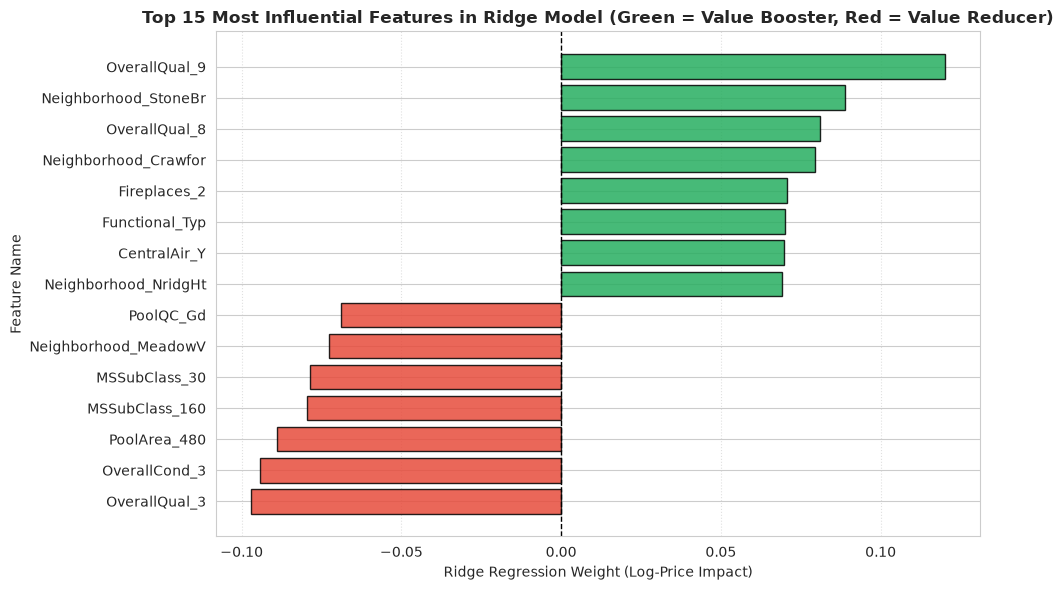

In [13]:
# ==============================================================================
# STEP 11: COEFFICIENT SHRINKAGE VISUALIZATION & FEATURE IMPORTANCE
# ==============================================================================

# 1. Extract All Feature Names (Continuous + One-Hot Dummy Names)
cat_names = list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
all_names = continuous_features + cat_names

# 2. Coefficients DataFrame
weights_df = pd.DataFrame({
    'Feature': all_names,
    'OLS_Weight': ols_model.coef_,
    'Ridge_Weight': ridge_model.coef_,
    'Ridge_Abs_Impact': np.abs(ridge_model.coef_)
})

# 3. Demonstrate Shrinkage Effect
max_ols = np.max(np.abs(weights_df['OLS_Weight']))
max_ridge = np.max(np.abs(weights_df['Ridge_Weight']))

print('=' * 65)
print('🔍 STEP 11: RIDGE COEFFICIENT SHRINKAGE PROOF')
print('=' * 65)
print(f'Max Absolute Weight in OLS   : {max_ols:.4f}')
print(f'Max Absolute Weight in Ridge : {max_ridge:.4f}')
print(f'Shrinkage Factor             : {((max_ols - max_ridge) / max_ols) * 100:.1f}% reduction in weight explosion!')
print('=' * 65)

# 4. Plot Top 15 Most Decisive Housing Features
top_15 = weights_df.sort_values(by='Ridge_Abs_Impact', ascending=False).head(15).sort_values(by='Ridge_Weight', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#27ae60' if w > 0 else '#e74c3c' for w in top_15['Ridge_Weight']]
plt.barh(top_15['Feature'], top_15['Ridge_Weight'], color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Top 15 Most Influential Features in Ridge Model (Green = Value Booster, Red = Value Reducer)', fontsize=12, fontweight='bold')
plt.xlabel('Ridge Regression Weight (Log-Price Impact)')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [14]:
# ==============================================================================
# STEP 12: ENTERPRISE PRODUCTION PIPELINE & MODEL SERIALIZATION
# ==============================================================================
import joblib
from pathlib import Path

# 1. Define Master End-to-End Pipeline
production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge(alpha=best_alpha, random_state=42))
])

# 2. Single Fit on Raw X_train and Log-Transformed Target
production_pipeline.fit(X_train, y_train_log)

# 3. Save Serialized Production Artifact (.joblib)
model_dir = Path('production_models')
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'house_price_ridge_pipeline.joblib'

joblib.dump(production_pipeline, model_path)

print('=' * 65)
print('🏭 ENTERPRISE PRODUCTION PIPELINE SUMMARY')
print('=' * 65)
print(f'✅ Full Pipeline Serialized Successfully to: {model_path}')
print(f'   Artifact Size: {model_path.stat().st_size / 1024:.2f} KB')

# 4. Live Production Inference Smoke Test (Single Unseen House)
loaded_pipeline = joblib.load(model_path)
sample_house = X_test.iloc[0:1]

predicted_log_price = loaded_pipeline.predict(sample_house)[0]
predicted_real_price = np.expm1(predicted_log_price)
actual_real_price = np.expm1(y_test_log.iloc[0])

print('\n🧪 Live Production Inference Smoke Test (1 House):')
print(f'   • Predicted Price : ${predicted_real_price:,.2f}')
print(f'   • Actual Price    : ${actual_real_price:,.2f}')
print(f'   • Difference      : ${abs(predicted_real_price - actual_real_price):,.2f} ({abs(predicted_real_price - actual_real_price)/actual_real_price*100:.1f}%)')
print('=' * 65)


🏭 ENTERPRISE PRODUCTION PIPELINE SUMMARY
✅ Full Pipeline Serialized Successfully to: production_models/house_price_ridge_pipeline.joblib
   Artifact Size: 23.71 KB

🧪 Live Production Inference Smoke Test (1 House):
   • Predicted Price : $147,058.44
   • Actual Price    : $154,500.00
   • Difference      : $7,441.56 (4.8%)
